# Week 1: Auditing algorithmic fairness with ACSIncome dataset

**Learning goals**

1. Separate a target label, a prediction, and a decision.
2. Validate performance and group fairness.
3. Connect independence, separation, sufficiency, and calibration to their assumptions.

**Project 1 (Week 1)**

1. Guided - Auditing algorithmic fairness with ACSIncome dataset
2. Transfer your learning and perform an audit on the Portuguese banking marketing campaign dataset


### Task 1: The task predicts whether annual income exceeds USD 50,000 using 2018 ACS data. `SEX` is the binary coding available in this survey extract. It is not a complete measurement of gender identity.

In [1]:
# pip -q install folktables fairlearn cleanlab scikit-learn pandas matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fairlearn

from IPython.display import display
from folktables import ACSDataSource, ACSIncome
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss,
    brier_score_loss, confusion_matrix, precision_score, recall_score,
)
from fairlearn.metrics import (
    MetricFrame, selection_rate, count, true_positive_rate,
    false_positive_rate, demographic_parity_difference,
    demographic_parity_ratio, equalized_odds_difference,
    equalized_odds_ratio,
)

RANDOM_STATE = 42
STATE = "CA"
MAX_SAMPLES = 50_000

## 1. Load and document the data

Before modelling, answer:

- What population is represented?
- What is the prediction target and who constructed it?
- Which variables are measurements, proxies, or administratively defined categories?
- Have a look at dataset description for code names ('columns') and their description - https://fairlearn.org/main/user_guide/datasets/acs_income.html

In [3]:
source = ACSDataSource(survey_year="2018", horizon="1-Year", survey="person")
acs = source.get_data(states=[STATE], download=True)
X_all, y_all, race_codes = ACSIncome.df_to_pandas(acs)

X_all = X_all.reset_index(drop=True)
y_reference = y_all.squeeze().astype(int).reset_index(drop=True)
race_codes = race_codes.squeeze().reset_index(drop=True)
sex_group = X_all["SEX"].map({1: "Male", 2: "Female"}).fillna("Unknown")
race_names = {
    1: "White", 2: "Black", 3: "American Indian", 4: "Alaska Native",
    5: "AIAN specified/other", 6: "Asian", 7: "Pacific Islander",
    8: "Other race", 9: "Two or more races",
}
race_group = race_codes.map(race_names).fillna("Unknown")

strata = y_reference.astype(str) + "_" + sex_group.astype(str)
if len(X_all) > MAX_SAMPLES:
    keep, _ = train_test_split(
        np.arange(len(X_all)), train_size=MAX_SAMPLES,
        random_state=RANDOM_STATE, stratify=strata,
    )
    X_all = X_all.iloc[keep].reset_index(drop=True)
    y_reference = y_reference.iloc[keep].reset_index(drop=True)
    sex_group = sex_group.iloc[keep].reset_index(drop=True)
    race_group = race_group.iloc[keep].reset_index(drop=True)

display(X_all.head())
display(pd.crosstab(sex_group, y_reference, normalize="index").rename(columns={0:"income<=50k",1:"income>50k"}))
print("Rows:", len(X_all), "Features:", X_all.shape[1])

,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P
0,47.0,1.0,22.0,1.0,5740.0,6.0,1.0,40.0,2.0,1.0
1,44.0,1.0,19.0,1.0,440.0,6.0,0.0,45.0,1.0,1.0
2,41.0,4.0,16.0,1.0,4220.0,12.0,0.0,42.0,1.0,1.0
3,58.0,1.0,18.0,5.0,3605.0,6.0,0.0,40.0,1.0,2.0
4,36.0,1.0,19.0,1.0,1006.0,361.0,5.0,40.0,1.0,1.0


PINCP,income<=50k,income>50k
SEX,,
Female,0.650932,0.349068
Male,0.534432,0.465568


Rows: 50000 Features: 10


### Label notation used throughout the course

| Symbol | Meaning | Use |
|---|---|---|
| $Y^{ref}$ | Best available reference outcome | Final validation and test audit |
| $Y^{obs}$ | Label available to us; in real-life | Training and realistic validation |
| $S=P(\hat Y=1)$ | Model score | Ranking and calibration |
| $\hat Y$ | Thresholded or postprocessed decision | Decision metrics |

In Week 1, $Y^{obs}=Y^{ref}$. Later weeks deliberately separate them. “Reference” is more accurate than “ground truth”: real labels can still be incomplete or contestable.

In [4]:
idx = np.arange(len(X_all))
strata = y_reference.astype(str) + "_" + sex_group.astype(str)
train_idx, temp_idx = train_test_split(idx, test_size=.40, random_state=RANDOM_STATE, stratify=strata)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=.50, random_state=RANDOM_STATE,
    stratify=strata.iloc[temp_idx],
)

def take(x, ids):
    return x.iloc[ids].reset_index(drop=True)

X_train, X_val, X_test = [take(X_all, z) for z in (train_idx, val_idx, test_idx)]
y_train, y_val, y_test = [take(y_reference, z) for z in (train_idx, val_idx, test_idx)]
A_train, A_val, A_test = [take(sex_group, z) for z in (train_idx, val_idx, test_idx)]
R_train, R_val, R_test = [take(race_group, z) for z in (train_idx, val_idx, test_idx)]

display(pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n": [len(X_train), len(X_val), len(X_test)],
    "positive_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    "female_fraction": [(A_train=="Female").mean(), (A_val=="Female").mean(), (A_test=="Female").mean()],
}))

,split,n,positive_rate,female_fraction
0,train,30000,0.4106,0.472
1,validation,10000,0.4105,0.472
2,test,10000,0.4106,0.472


## 2. Fit a transparent baseline

We retain `SEX` and `RAC1P` for the first model. (Later, compare a model that excludes them.)

**Removing a sensitive attribute does not remove proxies and is not itself a fairness guarantee** - We discuss this in lecture

In [5]:
NUMERIC = ["AGEP", "WKHP"]

def make_model(frame, C=1.0):
    numeric = [c for c in NUMERIC if c in frame.columns]
    categorical = [c for c in frame.columns if c not in numeric]
    prep = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ])
    return Pipeline([
        ("preprocess", prep),
        ("model", LogisticRegression(max_iter=1000, C=C)),
    ])

FEATURES = list(X_train.columns)
model = make_model(X_train[FEATURES])
model.fit(X_train[FEATURES], y_train)
val_score = model.predict_proba(X_val[FEATURES])[:, 1]
val_pred = (val_score >= .50).astype(int)

## 3. Metric families

| Family | Examples | Question | Important limitation |
|---|---|---|---|
| Performance | Accuracy, balanced accuracy, AUROC, log loss | Does the model work overall? | Can conceal subgroup failures |
| Independence | Selection rate, demographic parity difference/ratio | Are decisions distributed similarly? | Ignores the reference outcome |
| Separation | TPR/FPR, equal opportunity, equalized odds | Are errors similar conditional on $Y$? | Depends directly on label validity |
| Sufficiency | PPV/NPV | Does a decision mean the same thing across groups? | Threshold-dependent and unstable in small groups |

There is no universally correct fairness metric. The choice depends on the decision, harms, label-generating process, and deployment context.

Read the documentation of fairlearn.metrics and sklearn.metrics to identify the performance measures needed to assess Independence, Separation (Equalized Odds), Equal Opportunity, and Sufficiency. Add them to the analysis of the classifier as illustrated above, and create fairness diagnostics metrics that consider a ratio of metrics for the groups at hand, in a way that is consistent with each of the fairness criteria.

If you apply the standard practice of "more than 20% discrepancy is a problem" -- which combinations of datasets and fairness criteria lead to a conclusion of problematic bias?

In [6]:
# Custom fairness/performance metrics, implemented from the confusion matrix directly

def false_positive_rate_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else np.nan

def true_negative_rate_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan

def negative_predictive_value_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fn) if (tn + fn) > 0 else np.nan

metrics = {
    "n": count,
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "selection_rate": selection_rate,
    "TPR_recall": recall_score,
    "FPR": false_positive_rate_metric,
    "PPV_precision": lambda y, p: precision_score(y, p, zero_division=0),
    "NPV": negative_predictive_value_metric,
    "TNR": true_negative_rate_metric,
}

mf = MetricFrame(metrics=metrics, y_true=y_val, y_pred=val_pred, sensitive_features=A_val)

print("Overall threshold metrics")
display(pd.Series(mf.overall))
print("By group")
display(mf.by_group)
print("Maximum minus minimum")
display(pd.Series(mf.difference(method="between_groups")))
print("Minimum divided by maximum")
display(pd.Series(mf.ratio(method="between_groups")))

# Fairness diagnostics: independence (demographic parity) and separation (equalized odds),
# each as both a difference (max-min) and a ratio (min/max) across SEX groups.
fairness_summary = pd.Series({
    "demographic_parity_difference": demographic_parity_difference(y_val, val_pred, sensitive_features=A_val),
    "demographic_parity_ratio": demographic_parity_ratio(y_val, val_pred, sensitive_features=A_val),
    "equalized_odds_difference": equalized_odds_difference(y_val, val_pred, sensitive_features=A_val),
    "equalized_odds_ratio": equalized_odds_ratio(y_val, val_pred, sensitive_features=A_val),
})
print("Fairness summary (SEX)")
display(fairness_summary)

def flag_20pct_rule(name, value):
    # "differences" are flagged above 0.20; "ratios" are flagged below 0.80 (the four-fifths rule)
    if "difference" in name:
        return "FLAG" if value > 0.20 else "ok"
    return "FLAG" if value < 0.80 else "ok"

print("Flag (>20% discrepancy rule): difference > 0.20 or ratio < 0.80")
display(pd.Series({k: flag_20pct_rule(k, v) for k, v in fairness_summary.items()}))

Overall threshold metrics


n                    10000.000000
accuracy                 0.818400
balanced_accuracy        0.812389
selection_rate           0.410500
TPR_recall               0.778806
FPR                      0.154029
PPV_precision            0.778806
NPV                      0.845971
TNR                      0.845971
dtype: float64

By group


,n,accuracy,balanced_accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV,TNR
SEX,,,,,,,,,
Female,4720.0,0.817797,0.796255,0.339195,0.724954,0.132444,0.745784,0.854761,0.867556
Male,5280.0,0.818939,0.818678,0.474242,0.814890,0.177534,0.799920,0.836095,0.822466


Maximum minus minimum


...

n                    0.893939
accuracy             0.998605
balanced_accuracy    0.972611
selection_rate       0.715235
TPR_recall           0.889635
FPR                  0.746021
PPV_precision        0.932323
NPV                  0.978162
TNR                  0.948027
dtype: float64

Fairness summary (SEX)


demographic_parity_difference    0.135048
demographic_parity_ratio         0.715235
equalized_odds_difference        0.089936
equalized_odds_ratio             0.746021
dtype: float64

Flag (>20% discrepancy rule): difference > 0.20 or ratio < 0.80


demographic_parity_difference      ok
demographic_parity_ratio         FLAG
equalized_odds_difference          ok
equalized_odds_ratio             FLAG
dtype: str

In [7]:
overall_probability_metrics = pd.Series({
    "ROC_AUC": roc_auc_score(y_val, val_score),
    "log_loss": log_loss(y_val, val_score),
})
display(overall_probability_metrics)

prob_rows = []
for g in A_val.unique():
    m = A_val.eq(g).to_numpy()
    prob_rows.append({
        "group": g, "n": m.sum(),
        "ROC_AUC": roc_auc_score(y_val[m], val_score[m]),
        "log_loss": log_loss(y_val[m], val_score[m])
    })
display(pd.DataFrame(prob_rows).set_index("group"))

ROC_AUC     0.896257
log_loss    0.401263
dtype: float64

,n,ROC_AUC,log_loss
group,,,
Female,4720,0.893558,0.391373
Male,5280,0.894881,0.410104


### Interpretation checkpoint

Think:

1. Which group has the higher selection rate, and by how much?
2. Which group has the higher FPR and which has the higher TPR?
3. Does the direction of the PPV gap match the direction of the selection-rate gap?
4. What can you **not** conclude from these numbers alone?

**Optional: Write down your interpretation**
1. Selection rate comparison: ...
2. FPR/TPR comparison: ...
3. PPV gap vs. selection-rate gap: ...
4. What you cannot conclude: ...

## 4. Thresholds change decisions, not score quality

Inspect a threshold sweep. A fairness conclusion based on one arbitrary threshold is incomplete.

,threshold,accuracy,selection_gap,TPR_gap,FPR_gap
0,0.10,0.6803,0.109511,0.008602,0.090762
1,0.15,0.7248,0.113431,0.010343,0.082318
2,0.20,0.7579,0.116763,0.020991,0.070918
3,0.25,0.7800,0.123565,0.030407,0.070098
4,0.30,0.7942,0.130239,0.045087,0.068281
5,0.35,0.8051,0.131638,0.053676,0.062790
6,0.40,0.8121,0.133584,0.063461,0.058977
7,0.45,0.8173,0.134454,0.072664,0.054029
8,0.50,0.8184,0.135048,0.089936,0.045090
9,0.55,0.8172,0.134961,0.100911,0.040106


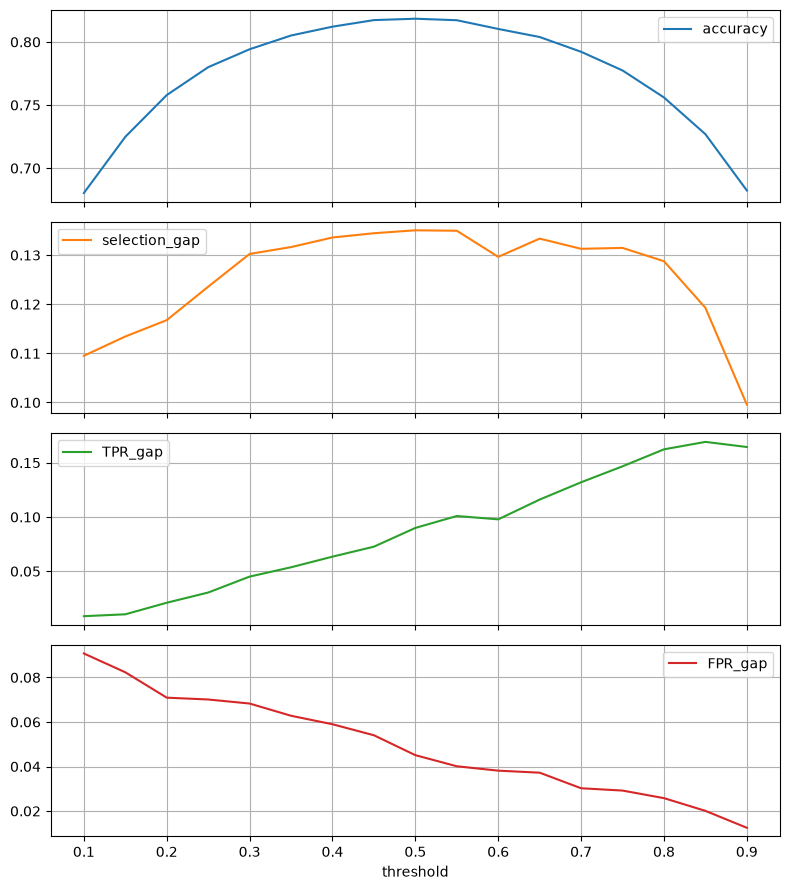

In [8]:
rows = []
for threshold in np.linspace(.1, .9, 17):
    pred = (val_score >= threshold).astype(int)
    frame = MetricFrame(
        metrics={"selection": selection_rate, "TPR": recall_score, "FPR": false_positive_rate_metric},
        y_true=y_val, y_pred=pred, sensitive_features=A_val,
    )
    rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val, pred),
        "selection_gap": frame.difference()["selection"],
        "TPR_gap": frame.difference()["TPR"],
        "FPR_gap": frame.difference()["FPR"],
    })
sweep = pd.DataFrame(rows)
display(sweep)
sweep.set_index("threshold").plot(subplots=True, figsize=(8,9), grid=True)
plt.tight_layout()

## 5. Sensitive-feature removal and intersectional audit

Complete both tasks. Report group-specific values and subgroup counts, not only gaps.

Removing sensitive-feature solve the problem? What are other short-comings you can think of?

In [9]:
# TODO 1: fit a second model after removing SEX and RAC1P from predictive features.
# Retain A_val and R_val for auditing.
FEATURES_WITHOUT_A = [c for c in FEATURES if c not in ["SEX", "RAC1P"]]

model_without_a = make_model(X_train[FEATURES_WITHOUT_A])
model_without_a.fit(X_train[FEATURES_WITHOUT_A], y_train)
score_without_a = model_without_a.predict_proba(X_val[FEATURES_WITHOUT_A])[:, 1]
pred_without_a = (score_without_a >= .50).astype(int)

audit_metrics = {
    "n": count,
    "accuracy": accuracy_score,
    "selection_rate": selection_rate,
    "TPR_recall": recall_score,
    "FPR": false_positive_rate_metric,
    "PPV_precision": lambda y, p: precision_score(y, p, zero_division=0),
}

mf_with_a = MetricFrame(metrics=audit_metrics, y_true=y_val, y_pred=val_pred, sensitive_features=A_val)
mf_without_a = MetricFrame(metrics=audit_metrics, y_true=y_val, y_pred=pred_without_a, sensitive_features=A_val)

print("Group-specific metrics, WITH SEX/RAC1P as features")
display(mf_with_a.by_group)
print("Group-specific metrics, WITHOUT SEX/RAC1P as features")
display(mf_without_a.by_group)

comparison = pd.DataFrame({
    "gap_with_SEX_RAC1P": mf_with_a.difference(method="between_groups"),
    "gap_without_SEX_RAC1P": mf_without_a.difference(method="between_groups"),
})
print("SEX-group gaps (max-min): does removing the sensitive attribute close them?")
display(comparison)

print("Overall accuracy, with vs. without SEX/RAC1P")
display(pd.Series({
    "accuracy_with_A": accuracy_score(y_val, val_pred),
    "accuracy_without_A": accuracy_score(y_val, pred_without_a),
}))

Group-specific metrics, WITH SEX/RAC1P as features


,n,accuracy,selection_rate,TPR_recall,FPR,PPV_precision
SEX,,,,,,
Female,4720.0,0.817797,0.339195,0.724954,0.132444,0.745784
Male,5280.0,0.818939,0.474242,0.814890,0.177534,0.799920


Group-specific metrics, WITHOUT SEX/RAC1P as features


,n,accuracy,selection_rate,TPR_recall,FPR,PPV_precision
SEX,,,,,,
Female,4720.0,0.819068,0.365890,0.765027,0.151969,0.729589
Male,5280.0,0.819886,0.450568,0.790480,0.154500,0.816730


SEX-group gaps (max-min): does removing the sensitive attribute close them?


,gap_with_SEX_RAC1P,gap_without_SEX_RAC1P
n,560.000000,560.000000
accuracy,0.001143,0.000819
selection_rate,0.135048,0.084678
TPR_recall,0.089936,0.025453
FPR,0.045090,0.002532
PPV_precision,0.054136,0.087141


Overall accuracy, with vs. without SEX/RAC1P


accuracy_with_A       0.8184
accuracy_without_A    0.8195
dtype: float64

In [10]:
# TODO 2: create an intersectional sensitive feature such as SEX x RACE.
# Require a minimum group size before interpreting a result.
MIN_GROUP_SIZE = 30

intersection = A_val.astype(str) + " | " + R_val.astype(str)
counts = intersection.value_counts()
display(counts.head(15))

valid_groups = counts[counts >= MIN_GROUP_SIZE].index
mask = intersection.isin(valid_groups).to_numpy()
print(f"Keeping {mask.sum()} / {len(mask)} validation rows across "
      f"{len(valid_groups)} intersectional groups with n >= {MIN_GROUP_SIZE} "
      f"(dropped {len(counts) - len(valid_groups)} tiny groups)")

mf_intersect = MetricFrame(
    metrics=audit_metrics,
    y_true=y_val[mask],
    y_pred=val_pred[mask],
    sensitive_features=intersection[mask],
)

print("By intersectional group (SEX | RACE), sorted by selection rate")
display(mf_intersect.by_group.sort_values("selection_rate"))
print("Intersectional gap (max-min across SEX x RACE groups)")
display(pd.Series(mf_intersect.difference(method="between_groups")))
print("Compare to the SEX-only gap computed above:")
display(pd.Series(mf_with_a.difference(method="between_groups")))

Male | White                   3337
Female | White                 2802
Female | Asian                  894
Male | Asian                    822
Male | Other race               655
Female | Other race             541
Female | Black                  239
Male | Black                    200
Male | Two or more races        198
Female | Two or more races      192
Male | American Indian           36
Female | American Indian         23
Female | Pacific Islander        20
Male | Pacific Islander          19
Male | AIAN specified/other      13
Name: count, dtype: int64

Keeping 9916 / 10000 validation rows across 11 intersectional groups with n >= 30 (dropped 6 tiny groups)


By intersectional group (SEX | RACE), sorted by selection rate


,n,accuracy,selection_rate,TPR_recall,FPR,PPV_precision
sensitive_feature_0,,,,,,
Female | Other race,541.0,0.872458,0.099815,0.405063,0.047619,0.592593
Male | Other race,655.0,0.824427,0.172519,0.493976,0.063395,0.725664
Male | American Indian,36.0,0.833333,0.250000,0.636364,0.080000,0.777778
Female | Two or more races,192.0,0.833333,0.265625,0.655738,0.083969,0.784314
Female | Black,239.0,0.794979,0.288703,0.616279,0.104575,0.768116
Female | White,2802.0,0.809422,0.367595,0.744094,0.153415,0.733981
Male | Black,200.0,0.750000,0.395000,0.710145,0.229008,0.620253
Male | Two or more races,198.0,0.823232,0.419192,0.815789,0.172131,0.746988
Female | Asian,894.0,0.814318,0.434004,0.780303,0.158635,0.796392


Intersectional gap (max-min across SEX x RACE groups)


n                 3301.000000
accuracy             0.122458
selection_rate       0.473178
TPR_recall           0.461603
FPR                  0.195275
PPV_precision        0.222456
dtype: float64

Compare to the SEX-only gap computed above:


n                 560.000000
accuracy            0.001143
selection_rate      0.135048
TPR_recall          0.089936
FPR                 0.045090
PPV_precision       0.054136
dtype: float64

## Task 2: Perform fairness auditing on a marketing campaign dataset

Repeat the analysis on a new dataset - https://fairlearn.org/v0.13/api_reference/generated/fairlearn.datasets.fetch_bank_marketing.html

What do you learn about bias diagnostic? How are these metrics different?

### 1. Load and document the data (Bank Marketing)

- **Population**: clients of a Portuguese bank contacted during direct-marketing (phone) campaigns, 2008-2010.
- **Target**: whether the client subscribed to a term deposit (`y`). Constructed by the bank from campaign records, not self-reported or independently audited.
- **Sensitive attribute**: `age` (numeric). We bin it into `<25`, `25-60`, `>60` — mirroring the age bands used in age-discrimination law/fairness literature, since raw continuous age isn't a usable "group" for selection-rate style metrics.
- **Data-quality note**: `duration` (last contact duration, in seconds) is called out in the official dataset documentation as a leakage feature — it is only known *after* the call happens and almost perfectly determines the outcome (a long call usually means the client said yes). We drop it from the predictive feature set to keep the audit realistic, the same way Week 2/3 will ask us to interrogate whether a feature is a legitimate predictor or an artifact of the collection process.

In [11]:
from fairlearn.datasets import fetch_bank_marketing

bank = fetch_bank_marketing(as_frame=True)
X_bank_all = bank.data.copy()
# V1=age, V6=balance, V10=day, V12=duration, V13=campaign, V14=pdays, V15=previous (rest categorical)
X_bank_all = X_bank_all.rename(columns={
    "V1": "age", "V2": "job", "V3": "marital", "V4": "education", "V5": "default",
    "V6": "balance", "V7": "housing", "V8": "loan", "V9": "contact", "V10": "day",
    "V11": "month", "V12": "duration", "V13": "campaign", "V14": "pdays",
    "V15": "previous", "V16": "poutcome",
})
# Class '2' is the minority "yes" (subscribed) class; confirmed via the dataset DESCR base rate (~11.7%)
y_bank_all = (bank.target.astype(str) == "2").astype(int).reset_index(drop=True)
X_bank_all = X_bank_all.reset_index(drop=True)

age_bins = [0, 25, 60, 200]
age_labels = ["<25", "25-60", ">60"]
age_group_bank = pd.cut(X_bank_all["age"], bins=age_bins, labels=age_labels, right=False)

BANK_FEATURES = [c for c in X_bank_all.columns if c != "duration"]  # drop leakage feature

display(X_bank_all[BANK_FEATURES].head())
display(pd.crosstab(age_group_bank, y_bank_all, normalize="index").rename(columns={0: "no", 1: "yes"}))
print("Rows:", len(X_bank_all), "Features used:", len(BANK_FEATURES))
print("Overall subscription rate:", round(y_bank_all.mean(), 4))

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown


Class,no,yes
age,,
<25,0.744129,0.255871
25-60,0.894833,0.105167
>60,0.663677,0.336323


Rows: 45211 Features used: 15
Overall subscription rate: 0.117


In [12]:
idx_bank = np.arange(len(X_bank_all))
strata_bank = y_bank_all.astype(str) + "_" + age_group_bank.astype(str)
train_idx_b, temp_idx_b = train_test_split(
    idx_bank, test_size=.40, random_state=RANDOM_STATE, stratify=strata_bank
)
val_idx_b, test_idx_b = train_test_split(
    temp_idx_b, test_size=.50, random_state=RANDOM_STATE, stratify=strata_bank.iloc[temp_idx_b]
)

Xb_train, Xb_val, Xb_test = [take(X_bank_all, z) for z in (train_idx_b, val_idx_b, test_idx_b)]
yb_train, yb_val, yb_test = [take(y_bank_all, z) for z in (train_idx_b, val_idx_b, test_idx_b)]
Ab_train, Ab_val, Ab_test = [take(age_group_bank, z) for z in (train_idx_b, val_idx_b, test_idx_b)]

display(pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n": [len(Xb_train), len(Xb_val), len(Xb_test)],
    "positive_rate": [yb_train.mean(), yb_val.mean(), yb_test.mean()],
}))
display(Ab_val.value_counts())

BANK_NUMERIC = ["age", "balance", "day", "campaign", "pdays", "previous"]

def make_bank_model(frame, numeric=BANK_NUMERIC, C=1.0):
    numeric = [c for c in numeric if c in frame.columns]
    categorical = [c for c in frame.columns if c not in numeric]
    prep = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ])
    return Pipeline([
        ("preprocess", prep),
        ("model", LogisticRegression(max_iter=1000, C=C)),
    ])

bank_model = make_bank_model(Xb_train[BANK_FEATURES])
bank_model.fit(Xb_train[BANK_FEATURES], yb_train)
val_score_bank = bank_model.predict_proba(Xb_val[BANK_FEATURES])[:, 1]
val_pred_bank = (val_score_bank >= .50).astype(int)

print("Bank marketing baseline fitted. Validation accuracy:", round(accuracy_score(yb_val, val_pred_bank), 4))

,split,n,positive_rate
0,train,27126,0.116973
1,validation,9042,0.117010
2,test,9043,0.116997


age
25-60    8523
>60       356
<25       163
Name: count, dtype: int64

Bank marketing baseline fitted. Validation accuracy: 0.8935


In [13]:
mf_bank = MetricFrame(metrics=metrics, y_true=yb_val, y_pred=val_pred_bank, sensitive_features=Ab_val)

print("Overall threshold metrics (Bank Marketing)")
display(pd.Series(mf_bank.overall))
print("By age group")
display(mf_bank.by_group)
print("Maximum minus minimum")
display(pd.Series(mf_bank.difference(method="between_groups")))
print("Minimum divided by maximum")
display(pd.Series(mf_bank.ratio(method="between_groups")))

fairness_summary_bank = pd.Series({
    "demographic_parity_difference": demographic_parity_difference(yb_val, val_pred_bank, sensitive_features=Ab_val),
    "demographic_parity_ratio": demographic_parity_ratio(yb_val, val_pred_bank, sensitive_features=Ab_val),
    "equalized_odds_difference": equalized_odds_difference(yb_val, val_pred_bank, sensitive_features=Ab_val),
    "equalized_odds_ratio": equalized_odds_ratio(yb_val, val_pred_bank, sensitive_features=Ab_val),
})
print("Fairness summary (age group)")
display(fairness_summary_bank)
print("Flag (>20% discrepancy rule)")
display(pd.Series({k: flag_20pct_rule(k, v) for k, v in fairness_summary_bank.items()}))

Overall threshold metrics (Bank Marketing)


n                    9042.000000
accuracy                0.893497
balanced_accuracy       0.590812
selection_rate          0.035280
TPR_recall              0.195652
FPR                     0.014028
PPV_precision           0.648903
NPV                     0.902442
TNR                     0.985972
dtype: float64

By age group


,n,accuracy,balanced_accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV,TNR
age,,,,,,,,,
25-60,8523.0,0.902616,0.577706,0.027220,0.166295,0.010882,0.642241,0.909902,0.989118
<25,163.0,0.779141,0.641381,0.147239,0.357143,0.074380,0.625000,0.805755,0.925620
>60,356.0,0.727528,0.636794,0.176966,0.358333,0.084746,0.682540,0.737201,0.915254


Maximum minus minimum


...

n                    0.019125
accuracy             0.806021
balanced_accuracy    0.900722
selection_rate       0.153817
TPR_recall           0.464078
FPR                  0.128412
PPV_precision        0.915698
NPV                  0.810198
TNR                  0.925324
dtype: float64

Fairness summary (age group)


demographic_parity_difference    0.149746
demographic_parity_ratio         0.153817
equalized_odds_difference        0.192039
equalized_odds_ratio             0.128412
dtype: float64

Flag (>20% discrepancy rule)


demographic_parity_difference      ok
demographic_parity_ratio         FLAG
equalized_odds_difference          ok
equalized_odds_ratio             FLAG
dtype: str

In [14]:
overall_probability_metrics_bank = pd.Series({
    "ROC_AUC": roc_auc_score(yb_val, val_score_bank),
    "log_loss": log_loss(yb_val, val_score_bank),
})
display(overall_probability_metrics_bank)

prob_rows_bank = []
for g in Ab_val.dropna().unique():
    m = Ab_val.eq(g).to_numpy()
    prob_rows_bank.append({
        "group": g, "n": m.sum(),
        "ROC_AUC": roc_auc_score(yb_val[m], val_score_bank[m]),
        "log_loss": log_loss(yb_val[m], val_score_bank[m]),
    })
display(pd.DataFrame(prob_rows_bank).set_index("group"))

ROC_AUC     0.768498
log_loss    0.299294
dtype: float64

,n,ROC_AUC,log_loss
group,,,
25-60,8523,0.752985,0.284366
<25,163,0.796734,0.471314
>60,356,0.725035,0.577902


### Threshold sweep and sensitive-feature removal (Bank Marketing)

The base rate here (~12% subscribe) is far more imbalanced than ACSIncome (~35-40% >$50k). Watch how that changes which threshold range is even informative, and how it affects the accuracy-vs-fairness trade-off.

,threshold,accuracy,selection_gap,TPR_gap,FPR_gap
0,0.050,0.360208,0.206080,0.092113,0.196367
1,0.075,0.514488,0.317357,0.183631,0.283606
2,0.100,0.667109,0.417060,0.237723,0.394916
3,0.125,0.775824,0.490315,0.359375,0.458412
4,0.150,0.834439,0.489923,0.402158,0.437786
5,0.175,0.863968,0.446021,0.350074,0.376474
6,0.200,0.876576,0.386260,0.296652,0.317379
7,0.225,0.883543,0.354691,0.305134,0.273308
8,0.250,0.886530,0.314565,0.260789,0.241072
9,0.275,0.890069,0.274438,0.261458,0.187257


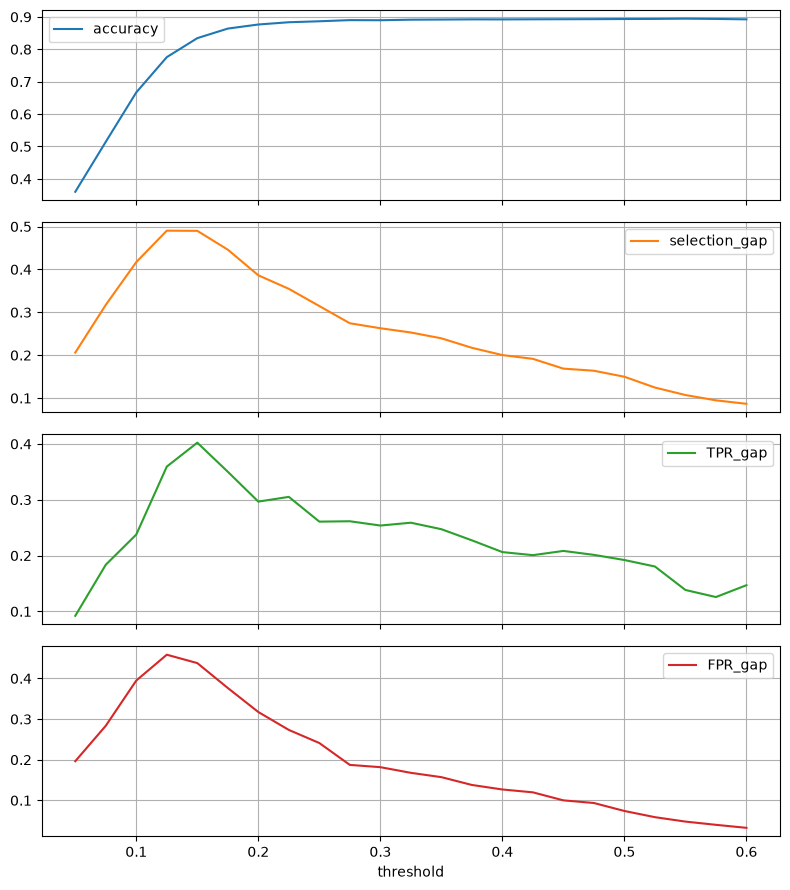

In [15]:
rows_bank = []
for threshold in np.linspace(.05, .60, 23):
    pred = (val_score_bank >= threshold).astype(int)
    frame = MetricFrame(
        metrics={"selection": selection_rate, "TPR": recall_score, "FPR": false_positive_rate_metric},
        y_true=yb_val, y_pred=pred, sensitive_features=Ab_val,
    )
    rows_bank.append({
        "threshold": threshold,
        "accuracy": accuracy_score(yb_val, pred),
        "selection_gap": frame.difference()["selection"],
        "TPR_gap": frame.difference()["TPR"],
        "FPR_gap": frame.difference()["FPR"],
    })
sweep_bank = pd.DataFrame(rows_bank)
display(sweep_bank)
sweep_bank.set_index("threshold").plot(subplots=True, figsize=(8,9), grid=True)
plt.tight_layout()

In [16]:
BANK_FEATURES_WITHOUT_A = [c for c in BANK_FEATURES if c != "age"]

bank_model_without_a = make_bank_model(Xb_train[BANK_FEATURES_WITHOUT_A])
bank_model_without_a.fit(Xb_train[BANK_FEATURES_WITHOUT_A], yb_train)
score_bank_without_a = bank_model_without_a.predict_proba(Xb_val[BANK_FEATURES_WITHOUT_A])[:, 1]
pred_bank_without_a = (score_bank_without_a >= .50).astype(int)

mf_bank_with_a = MetricFrame(metrics=audit_metrics, y_true=yb_val, y_pred=val_pred_bank, sensitive_features=Ab_val)
mf_bank_without_a = MetricFrame(metrics=audit_metrics, y_true=yb_val, y_pred=pred_bank_without_a, sensitive_features=Ab_val)

comparison_bank = pd.DataFrame({
    "gap_with_age": mf_bank_with_a.difference(method="between_groups"),
    "gap_without_age": mf_bank_without_a.difference(method="between_groups"),
})
print("Age-group gaps (max-min): does removing `age` as a feature close them?")
display(comparison_bank)

print("Overall accuracy, with vs. without age")
display(pd.Series({
    "accuracy_with_age": accuracy_score(yb_val, val_pred_bank),
    "accuracy_without_age": accuracy_score(yb_val, pred_bank_without_a),
}))

Age-group gaps (max-min): does removing `age` as a feature close them?


,gap_with_age,gap_without_age
n,8360.000000,8360.000000
accuracy,0.175088,0.175440
selection_rate,0.149746,0.149863
TPR_recall,0.192039,0.190923
FPR,0.073863,0.074126
PPV_precision,0.057540,0.033189


Overall accuracy, with vs. without age


accuracy_with_age       0.893497
accuracy_without_age    0.894050
dtype: float64

## 📝 Project 1 Submission Guidelines

**Format:** Project 1 will be submitted as an **A0 Poster**. 

**Week 1 Contribution:**
The findings and discussions generated from this Week 1 notebook should form the foundation of your project and cover approximately **1/3 of your final poster**. 

When preparing your poster, ensure that this section includes:
* Clearly outline the context, goals, and intended real-world impact of the model. 
* Explain what the different fairness metrics represent in the context of this specific use case (e.g., what does a disparity in False Positive Rate mean for the individuals actually affected?).
* Provide a short analysis of the bias present in the ACSIncome dataset and Bank Marketing dataset - from your exploratory data analysis and the fairness metric evaluations conducted in this notebook.